### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [498]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [499]:
data = pd.read_csv('data/coupons.csv')

In [500]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

Investigating Missing and Problematic Data

Before performing the analysis,examined the dataset for missing values, duplicate records, incorrect data types, and inconsistent categorical values. Identifying and handling problematic data is important to improve data quality and ensure reliable analysis results.

In [501]:
#display the shape of the data
print(f'shape of the data before preprocessing: {data.shape}')

shape of the data before preprocessing: (12684, 26)


Dataset contains mostly categorical variable

In [502]:
#check data types of the columns
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

In [503]:
#calculating missing values in the each columndata
missing_values = data.isnull().sum()
print(f'missing values in each column:\n{missing_values[missing_values>0]}')


missing values in each column:
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
dtype: int64


Findings from Missing Data Investigation

The car column contained an extremely high number of missing values (~99.1% of the observations).
Several other columns (Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, and Restaurant20To50) contained relatively small numbers of missing values. 

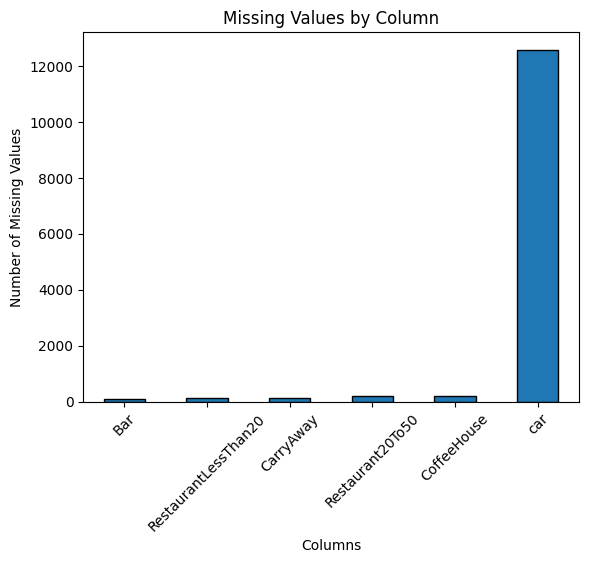

In [504]:
#visualize missing values

(missing_values[missing_values > 0]).sort_values(ascending=True).plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

3. Decide what to do about your missing data -- drop, replace, other...

Handling Missing Data

The dataset contained missing values in several columns. The car column had an extremely high percentage of missing values (more than 99% missing). Because the amount of missing data was too large to reliably impute, this column was removed from the analysis.

Other columns (Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, and Restaurant20To50) contained relatively small numbers of missing values. Since these are categorical variables, the missing values were replaced using the mode (most frequent category) in order to preserve the majority distribution of the dataset while minimizing information loss.

In [505]:
#creating a copy of the data for preprocessing
data_preprocessed = data.copy()

#dropping the car column as it has a high percentage of missing values
data_preprocessed.drop(columns=['car'], inplace=True)



In [506]:
#replacing missing values for other columns using mode as the data is categorical

for column in data_preprocessed.columns:
    if data_preprocessed[column].isnull().sum() > 0:
        mode_value = data_preprocessed[column].mode()[0]
        data_preprocessed[column] = data_preprocessed[column].fillna(mode_value)



In [507]:
# checking null values after preprocessing
missing_values_after = data_preprocessed.isnull().sum()
print(f'missing values in each column after preprocessing:\n{missing_values_after[missing_values_after > 0]}')

missing values in each column after preprocessing:
Series([], dtype: int64)


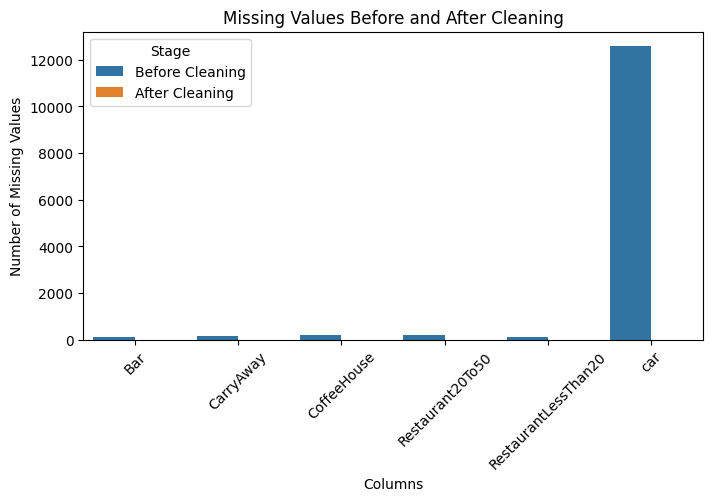

In [508]:
# visualize missing values before and after preprocessing


# Combine into one dataframe
missing_df = pd.DataFrame({
    'Before Cleaning': missing_values,
    'After Cleaning': missing_values_after
})

# Keep only columns with missing values originally
missing_df = missing_df[missing_df['Before Cleaning'] > 0]

# Convert to long format for seaborn
missing_long = missing_df.reset_index().melt(
    id_vars='index',
    var_name='Stage',
    value_name='Missing Count'
)

# Rename column names
missing_long.rename(columns={'index': 'Columns'}, inplace=True)

# Plot
plt.figure(figsize=(8,4))

sns.barplot(
    data=missing_long,
    x='Columns',
    y='Missing Count',
    hue='Stage'
)

plt.xticks(rotation=45)

plt.title('Missing Values Before and After Cleaning')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')

plt.show()

Findings: No missing values in dataset after cleanup.

Handling Duplicates, spaces, spelling mistakes and merging two columns in one.

The dataset was further inspected for duplicate records, inconsistent spacing in categorical variables, spelling inconsistencies in column names and combining binary columns into single one. Duplicate observations can bias statistical analysis, so duplicate rows were identified and removed.

In addition, leading and trailing whitespace characters were removed from string columns to ensure consistent categorical values during analysis and visualization. This preprocessing step helps prevent values such as "Male" and " Male" from being treated as different categories.

The binary columns direction_same and direction_opp were combined into a single categorical column called direction.

Finally, spelling inconsistencies in column names were corrected to improve readability and maintain consistency throughout the analysis. For example, the column name passanger was corrected to passenger.

Outlier Analysis

I explored potential outliers in the numerical variables  using IQR method. However, the dataset mainly contains categorical and binary variables with limited numerical variation. As a result, no major or meaningful outliers were observed in the preprocessed dataset.



In [509]:
# duplicate rows in the data, if any
duplicate_rows = data_preprocessed.duplicated().sum()
print(f'number of duplicate rows in the data: {duplicate_rows}')

number of duplicate rows in the data: 74


In [510]:
#dropping duplicate rows
data_preprocessed.drop_duplicates(inplace=True)
print(f'number of duplicate rows after cleaning: {data_preprocessed.duplicated().sum()}')

number of duplicate rows after cleaning: 0


In [511]:
#stripping the leading and trailing spaces from the string columns
obj_cols = data_preprocessed.select_dtypes(
    include=['object', 'string']
).columns
data_preprocessed[obj_cols] = data_preprocessed[obj_cols].apply(lambda x: x.str.strip())

In [512]:
#correcting spelling mistakes in the 'passanger' column
data_preprocessed=data_preprocessed.rename(columns={'passanger': 'passenger'})
print(data_preprocessed.columns)


Index(['destination', 'passenger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min',
       'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same',
       'direction_opp', 'Y'],
      dtype='str')


In [513]:
#merging two columns 'direction_same' and 'direction_opp' into a single column 'direction' and dropping the original columns
data_preprocessed['direction'] = np.where(data_preprocessed['direction_same'] == 1, 'same_direction', 'opposite_direction')
data_preprocessed.drop(columns=['direction_same', 'direction_opp'], inplace=True)


Combining Direction Features

The binary columns direction_same and direction_opp were merged into a single categorical column called direction. This simplifies interpretation by representing whether the coupon venue was in the same or opposite direction as the driver’s destination. After creating the new feature, the original binary columns were removed to avoid redundancy.

In [514]:
data_preprocessed.head()


,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,Y,direction
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,0,0,1,opposite_direction
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,0,0,0,opposite_direction
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,1,0,1,opposite_direction
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,1,0,0,opposite_direction
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,1,0,0,opposite_direction


In [515]:
#outliers detection using IQR method

# Identify numeric columns for outlier detection
numeric_cols = data_preprocessed.select_dtypes(
    include=['int64', 'float64']
).columns

print(f'Numeric columns for outlier detection: {numeric_cols}')

for col in numeric_cols:

    Q1 = data_preprocessed[col].quantile(0.25)
    Q3 = data_preprocessed[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data_preprocessed[
        (data_preprocessed[col] < lower) |
        (data_preprocessed[col] > upper)
    ]

    print(f'{col}: {len(outliers)} outliers')

Numeric columns for outlier detection: Index(['temperature', 'has_children', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min',
       'toCoupon_GEQ25min', 'Y'],
      dtype='str')
temperature: 0 outliers
has_children: 0 outliers
toCoupon_GEQ5min: 0 outliers
toCoupon_GEQ15min: 0 outliers
toCoupon_GEQ25min: 1463 outliers
Y: 0 outliers


--------------------------Key findings from data preprocessing----------------------------------

.The dataset contained missing values in a few columns, which were identified and handled before analysis.

.Most variables in the dataset were categorical, requiring preprocessing and restructuring for visualization and analysis.

.The dataset showed very limited numerical variation, with many binary and ordinal categorical variables.

.Outlier analysis using  IQR method did not reveal any major or meaningful outliers.

.Cleaning and preprocessing improved the readability and consistency of the dataset for exploratory analysis.

4. What proportion of the total observations chose to accept the coupon?



In [516]:
#proportion of customers who accepted the coupons
accepted_rate = data_preprocessed['Y'].mean()
print(f"Proportion of customers who accepted the coupons: {accepted_rate:.2f}")

Proportion of customers who accepted the coupons: 0.57


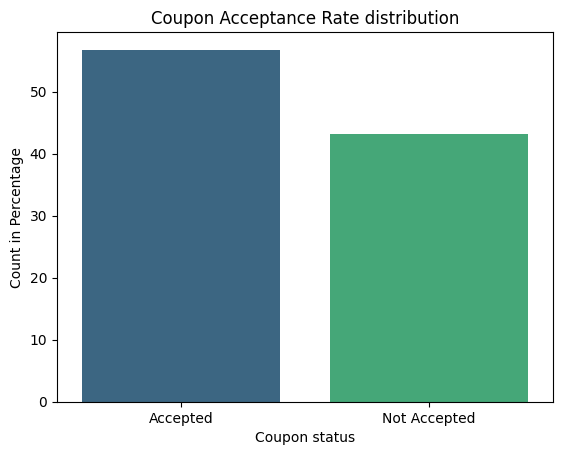

In [517]:
#Visualize the distribution of the coupon acceptance rate
accepted_rate_percentage = accepted_rate * 100

sns.barplot(x=['Accepted', 'Not Accepted'], y=[accepted_rate_percentage, 100 - accepted_rate_percentage], hue=['Accepted', 'Not Accepted'], palette='viridis')
plt.title('Coupon Acceptance Rate distribution')
plt.xlabel('Coupon status')
plt.ylabel('Count in Percentage')
plt.show()

Observation

The results show that a substantial proportion of customers accepted the coupon. The distribution also indicates that coupon acceptance behavior is relatively balanced, making the dataset suitable for further analysis and EDA

5. Use a bar plot to visualize the `coupon` column.

Distribution of Coupon Types

To better understand the dataset, a bar plot was created to visualize the frequency of different coupon types. This helps identify which coupons were offered most frequently to customers

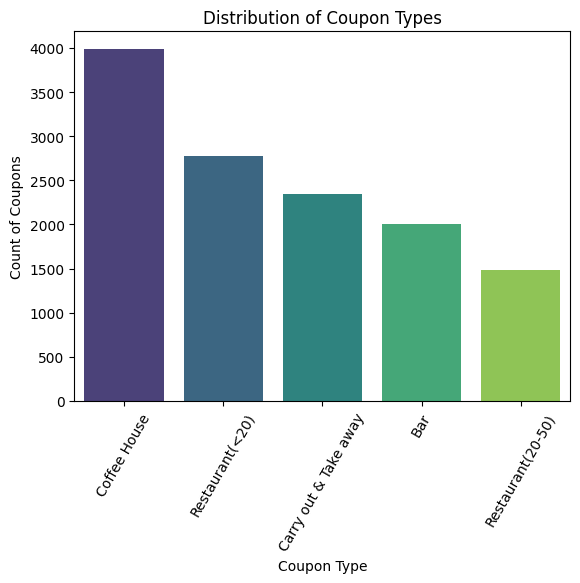

In [518]:
#Visualize the distribution of the coupon types

coupon_counts = data_preprocessed['coupon'].value_counts()

sns.barplot(x=coupon_counts.index, y=coupon_counts.values,hue=coupon_counts.index, palette='viridis')
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count of Coupons')
plt.xticks(rotation=60)
plt.show()



Observation

The bar plot shows that some coupon types were distributed more frequently than others. Coffee House appears to be the common coupon, while Slightly expensive restaurant coupons were less frequent in comparison. This distribution provides useful context for understanding customer acceptance behavior across different coupon types.

6. Use a histogram to visualize the temperature column.

Distribution of Temperature

A histogram was created to visualize the distribution of temperature in the dataset. This helps understand the environmental conditions under which coupons were offered and whether certain temperature ranges appeared more frequently.

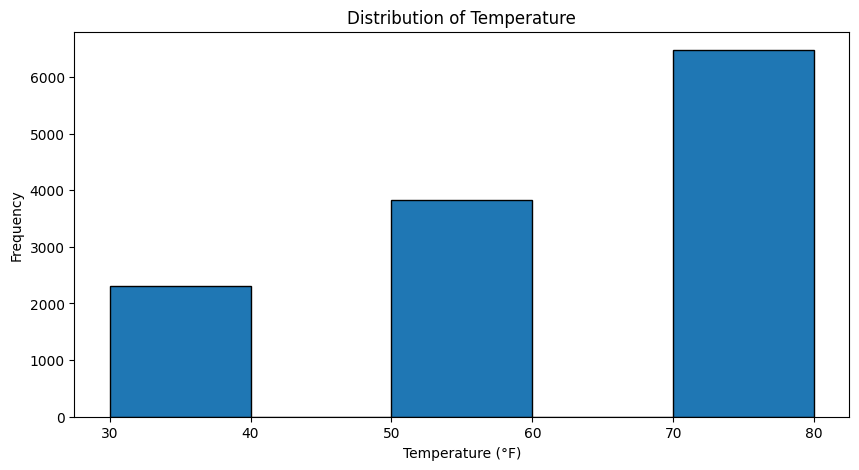

In [519]:
#Visualize the distribution of the temperature column
plt.figure(figsize=(10,5))
plt.hist(data_preprocessed['temperature'],  bins=5, edgecolor='black')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')
plt.show()


Observation

The histogram shows that coupon offers were distributed across a few discrete temperature values, with moderate and warmer temperatures appearing more frequently than colder conditions. This suggests that customer coupon activity in the dataset was more commonly observed during mild to warm weather conditions.

Coupon Acceptance Based on Direction

To investigate whether the direction of the coupon venue influenced customer decisions, coupon acceptance was analyzed for locations in the same direction as the driver’s destination versus the opposite direction. Both the total number of observations and the acceptance rates were visualized.



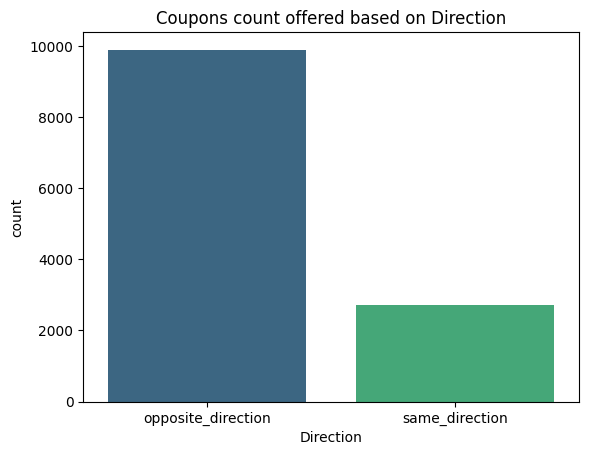

In [520]:
# Coupons offered to customer by Direction

data_preprocessed['direction'].value_counts()
sns.countplot(x='direction', data=data_preprocessed,hue='direction', palette='viridis')
plt.title('Coupons count offered based on Direction') 
plt.xlabel('Direction')
plt.ylabel('count')
plt.show()



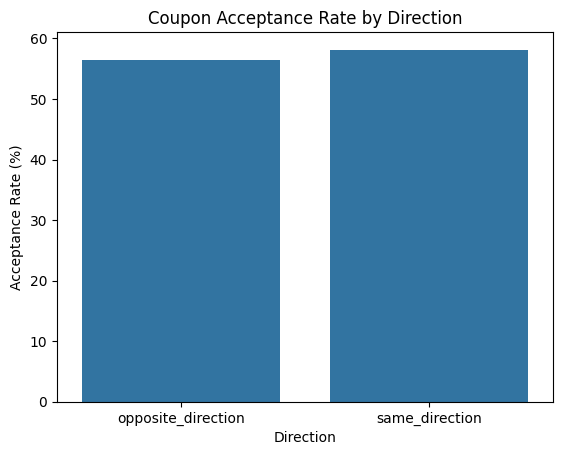

In [521]:
#Visualize the coupon acceptance rate by direction

direction_acceptance = (
    data_preprocessed
    .groupby('direction')['Y']
    .mean()
    .reset_index()
)

direction_acceptance['acceptance_rate'] = direction_acceptance['Y'] * 100

sns.barplot(
    x='direction',
    y='acceptance_rate',
    data=direction_acceptance
)

plt.title('Coupon Acceptance Rate by Direction')
plt.xlabel('Direction')
plt.ylabel('Acceptance Rate (%)')
plt.show()

Observation

The count plot shows that the dataset contains substantially more observations where the coupon venue was located in the opposite direction of the driver’s destination. However, the acceptance rate plot reveals that coupon acceptance rates were relatively similar between the two groups.

Customers traveling in the same direction as the coupon venue showed only a slightly higher acceptance rate compared to those traveling in the opposite direction. Overall, direction does not appear to have a strong influence on coupon acceptance behavior in this dataset.

This suggests that other factors such as coupon type, customer habits, age, passenger type, or dining preferences may play a larger role in determining whether a customer accepts a coupon


-----------------Investigating the Effect of Travel Direction and Travel Time on Coupon Acceptance-----------------

In this section, I explored whether the travel direction and estimated travel time to the coupon destination influence coupon acceptance behavior. The analysis focuses on the `toCoupon_GEQ5min`, `toCoupon_GEQ15min`, and `toCoupon_GEQ25min` features, which indicate whether the destination requires at least 5, 15, or 25 minutes of travel.

To better visualize these relationships, I used grouped acceptance rate calculations and heatmaps comparing travel direction with travel time conditions.



Acceptance Rate Analysis for toCoupon_GEQ5min

            direction toCoupon_GEQ5min         Y
0  opposite_direction              Yes  0.563688
1      same_direction              Yes  0.581678


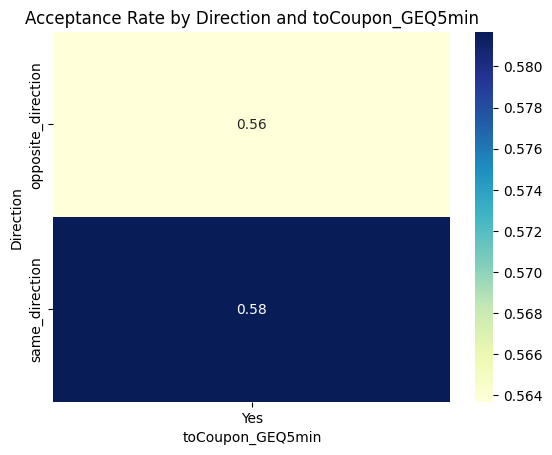


Acceptance Rate Analysis for toCoupon_GEQ15min

            direction toCoupon_GEQ15min         Y
0  opposite_direction                No  0.621471
1  opposite_direction               Yes  0.530958
2      same_direction                No  0.599797
3      same_direction               Yes  0.533602


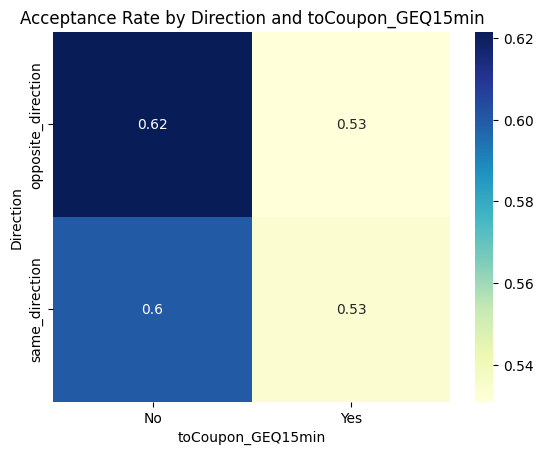


Acceptance Rate Analysis for toCoupon_GEQ25min

            direction toCoupon_GEQ25min         Y
0  opposite_direction                No  0.588682
1  opposite_direction               Yes  0.419686
2      same_direction                No  0.581678


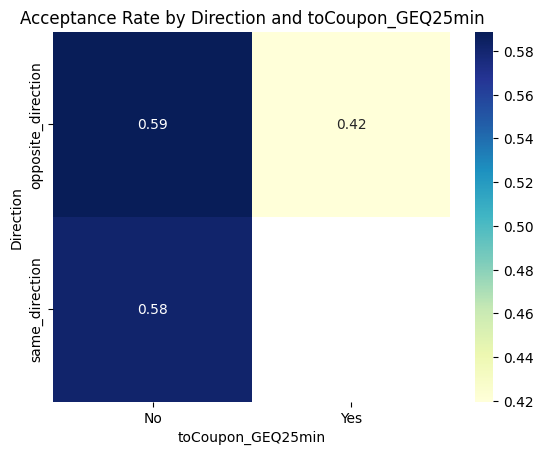

In [522]:
geq_cols = ['toCoupon_GEQ5min', 
            'toCoupon_GEQ15min', 
            'toCoupon_GEQ25min']

for col in geq_cols:
    
    GEQ= data_preprocessed.groupby(
        ['direction', col]
    )['Y'].mean().reset_index()

    #relabel 0 and 1
    GEQ[col] = GEQ[col].apply(
        lambda x: 'Yes' if x == 1 else 'No'
    )

    print(f'\nAcceptance Rate Analysis for {col}\n')
    print(GEQ)

    pivot = pd.pivot_table(
    GEQ,
    values='Y',
    index='direction',
    columns=col
)
    sns.heatmap(
    pivot,
    annot=True,
    cmap='YlGnBu'
)
    plt.title(f'Acceptance Rate by Direction and {col}')
    plt.xlabel(col)
    plt.ylabel('Direction')
    plt.show()

Observation:

Heatmap shows that coupon acceptance rates generally decreased as the required travel time increased. Drivers were more likely to accept coupons when the destination required less additional travel time,

| Travel Direction   | Travel Time Condition           | Acceptance Rate |
| ------------------ | ------------------------------- | --------------- |
| Opposite Direction | Less than 15 min                | 62%             |
| Opposite Direction | Greater than or equal to 15 min | 53%             |
| Same Direction     | Less than 15 min                | 60%             |
| Same Direction     | Greater than or equal to 15 min | 53%             |



Age Group vs Coupon Acceptance

To understand whether age influences customer behavior, coupon acceptance rates were compared across different age groups. This analysis helps identify whether certain age groups are more likely to accept coupons than others.

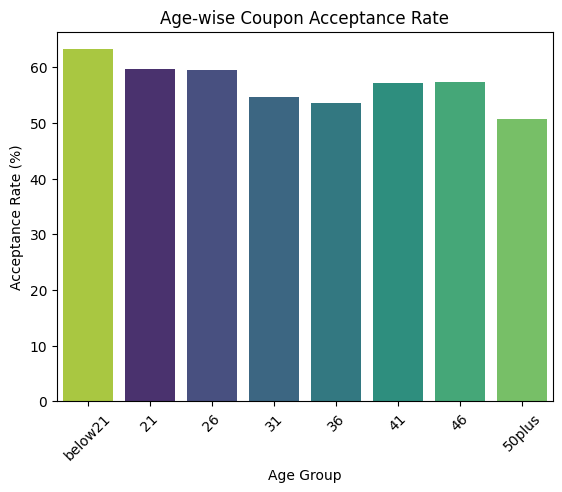

In [523]:
#calculate the acceptance rate by each age group
age_acceptance = (data_preprocessed.groupby('age')['Y'].mean() * 100).reset_index()


#age natural ordering
age_order = ['below21', '21', '26', '31', '36', '41', '46', '50plus']



sns.barplot(
    x='age',
    y='Y',
    data=age_acceptance,
    order=age_order,
    hue='age',
    palette='viridis'
)


plt.title('Age-wise Coupon Acceptance Rate')
plt.xlabel('Age Group')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=45)
plt.show()


Observation:

The visualization suggests that younger customers are generally more likely to accept coupons compared to older age groups. Customers in the below21, 21, and 26 age groups show the highest coupon acceptance rates, while the 50plus group has the lowest acceptance rate.Although the differences are moderate rather than dramatic, the overall trend indicates that coupon responsiveness tends to decrease slightly with age.

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [524]:
#creating a new dataframe for bar coupon
bar_coupon=data_preprocessed[data_preprocessed['coupon']=='Bar']

#shape of the bar coupon dataframe
print(f'shape of bar_coupon dataframe: {bar_coupon.shape}')


bar_coupon.head()

shape of bar_coupon dataframe: (2010, 24)


,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,Y,direction
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,1,0,0,opposite_direction
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,0,0,1,same_direction
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,1,1,0,opposite_direction
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,never,less1,4~8,4~8,less1,1,0,0,1,opposite_direction
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,never,less1,4~8,4~8,less1,1,0,0,1,same_direction


2. What proportion of bar coupons were accepted?


Bar Coupon Acceptance Rate

After isolating the bar coupon observations, the proportion of customers who accepted bar coupons was calculated. This helps measure how successful bar-related promotions were compared to overall coupon behavior.

In [525]:
#proportion of bar coupons accepted by customers
bar_accepted_rate = bar_coupon['Y'].mean()
print(f"Proportion of bar coupons accepted: {bar_accepted_rate:.2f}")
print(f"Percentage of bar coupons accepted: {bar_accepted_rate*100:.2f}%")

Proportion of bar coupons accepted: 0.41
Percentage of bar coupons accepted: 41.00%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


Bar Visit Frequency vs Coupon Acceptance

To investigate whether prior bar-going behavior influences coupon acceptance, the acceptance rates were compared between customers who visit bars three or fewer times per month and those who visit bars more frequently.

This analysis helps determine whether customers who already frequent bars are more likely to accept bar-related coupons.

In [526]:
# customers who visted a bar 3 or fewer times in the past month
bar_3_or_fewer = bar_coupon[bar_coupon['Bar'].isin(['never', 'less1', '1~3'])]

#calculate the acceptance rate
rate_3_or_fewer = bar_3_or_fewer['Y'].mean()
print(f"Proportion of bar coupons accepted by customers who visted a bar 3 or fewer times: {rate_3_or_fewer:.2f}")

#customers who visted a bar more than 3 times in the past month
bar_more = bar_coupon[bar_coupon['Bar'].isin(['4~8', 'gt8'])]

#calculate the acceptance rate
rate_more = bar_more['Y'].mean()
print(f"Proportion of bar coupons accepted by customers who visted a bar more than 3 times: {rate_more:.2f}")


Proportion of bar coupons accepted by customers who visted a bar 3 or fewer times: 0.37
Proportion of bar coupons accepted by customers who visted a bar more than 3 times: 0.77


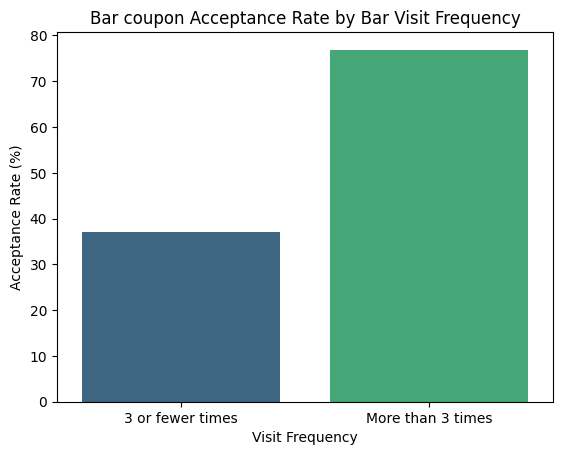

In [527]:
#visualization
accptance_rate_comp = pd.DataFrame({
    'Visit Frequency': ['3 or fewer times', 'More than 3 times'],
    'Acceptance Rate': [rate_3_or_fewer * 100, rate_more * 100]
})


sns.barplot(
    x='Visit Frequency',
    y='Acceptance Rate',
    data=accptance_rate_comp,
    hue='Visit Frequency',
    palette='viridis'
)

plt.title('Bar coupon Acceptance Rate by Bar Visit Frequency')
plt.xlabel('Visit Frequency')   
plt.ylabel('Acceptance Rate (%)')
plt.show()


Comparison

The analysis shows a clear difference in coupon acceptance behavior based on bar visit frequency. Customers who visit bars more than three times per month have a substantially higher acceptance rate compared to customers who visit bars less frequently.

This suggests that prior customer behavior is a strong predictor of coupon acceptance. Customers who already enjoy going to bars are naturally more responsive to bar-related promotions and offers.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [528]:
#customers over 25 years old and visted a bar more than once a month
group1 = bar_coupon[bar_coupon['age']
                            .isin(['26', '31', '36', '41', '46', '50plus']) 
                            & (bar_coupon['Bar']
                               .isin(['1~3', '4~8', 'gt8']))]


#calculate the acceptance rate 
rate_over_25 = group1['Y'].mean()
print(f"Proportion of coupons accepted by customers over 25: {rate_over_25:.2f}")

# rest of the customer that are not in group1
group2=data_preprocessed.drop(group1.index)

#calculate the acceptance rate
rate_rest = group2['Y'].mean()
print(f"Proportion of coupons accepted by the rest of customers: {rate_rest:.2f}")



Proportion of coupons accepted by customers over 25: 0.70
Proportion of coupons accepted by the rest of customers: 0.56


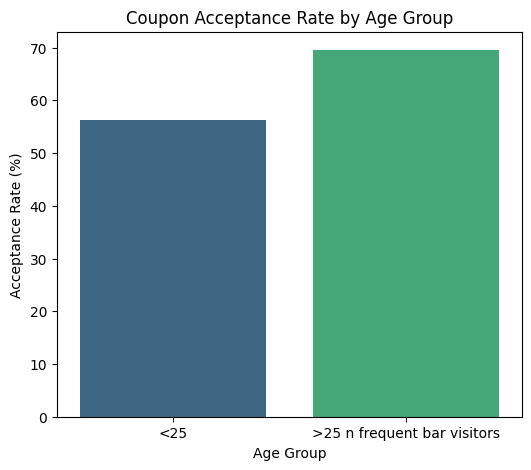

In [529]:
#Visualization
comparison_df = pd.DataFrame({
    'Age Group': ['<25', '>25 n frequent bar visitors'],
    'Acceptance Rate': [rate_rest * 100, rate_over_25 * 100]
})

plt.figure(figsize=(6,5))
sns.barplot(
    x='Age Group',
    y='Acceptance Rate',
    data=comparison_df,
    hue='Age Group',
    palette='viridis'
)


plt.title('Coupon Acceptance Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Acceptance Rate (%)')
plt.show()



Comparison and observation

The analysis shows a noticeable difference in coupon acceptance behavior between the two groups. Drivers who visit bars more than once a month and are older than 25 demonstrate a higher acceptance rate compared to all other drivers.

This suggests that established bar-going habits are strongly associated with coupon acceptance, even among older customers. Frequent exposure to bar environments may increase familiarity and responsiveness to bar-related promotions.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


Passenger Type and Occupation vs Bar Coupon Acceptance

The acceptance rates were compared between drivers who:

go to bars more than once a month,
had passengers that were not kids, and
worked in occupations other than Farming, Fishing & Forestry,

versus all other customers.

This analysis helps determine whether customer lifestyle and social behavior are associated with bar coupon acceptance.

In [530]:
#drivers visiting a bar more than once a month had passenger not a kid 
#and occupation other than farming, fishing, and forestry

group_3 = bar_coupon[
    (bar_coupon['Bar'].isin(['1~3','4~8', 'gt8'])) &
    (bar_coupon['passenger'] != 'Kid(s)') &
    (bar_coupon['occupation'] != 'Farming Fishing & Forestry')
]

#calculate the acceptance rate for this group
rate_group_3 = group_3['Y'].mean()

print(f"Proportion of coupons accepted by drivers visiting a bar more than once a month with specific passenger and occupation: {rate_group_3:.2f}")

# rest of the customers that are not in group_3
group_4 = bar_coupon.drop(group_3.index)

#calculate the acceptance rate for the rest of the customers
rate_group_4 = group_4['Y'].mean()
print(f"Proportion of coupons accepted by the rest of customers: {rate_group_4:.2f}")


Proportion of coupons accepted by drivers visiting a bar more than once a month with specific passenger and occupation: 0.71
Proportion of coupons accepted by the rest of customers: 0.30


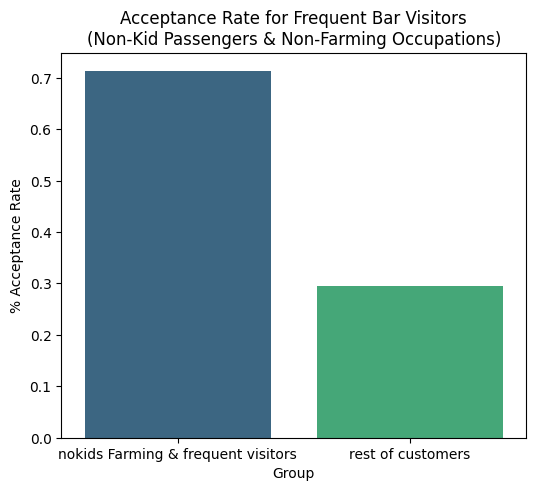

In [531]:
#visualization
group_comparison_df = pd.DataFrame({
    'Group': ['nokids Farming & frequent visitors', 'rest of customers'],
    'Acceptance Rate': [ rate_group_3, rate_group_4]
})

plt.figure(figsize=(6,5))
sns.barplot(
    x='Group',
    y='Acceptance Rate',
    data=group_comparison_df,
    hue='Group',
    palette='viridis'
)

plt.title("Acceptance Rate for Frequent Bar Visitors\n(Non-Kid Passengers & Non-Farming Occupations)")
plt.xlabel('Group')
plt.ylabel('% Acceptance Rate')
plt.show()

Comparison and Findings

The results indicate that customers who frequently visit bars, travel without kids, and work outside Farming, Fishing & Forestry occupations tend to have a higher bar coupon acceptance rate compared to the rest of the customers.

This suggests that social lifestyle patterns and customer demographics may influence responsiveness to bar-related promotions.

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [532]:
#customer going to bar frequently,with 'No kids' passengers, and are not widowed 

group_5 = bar_coupon[
    (bar_coupon['Bar'].isin(['1~3','4~8', 'gt8'])) &
    (bar_coupon['passenger'] != 'Kid(s)') & 
    (bar_coupon['maritalStatus'] != 'Widowed')
]

#customer going to bar frequently and under the age of 30
group_6=bar_coupon[
    (bar_coupon['Bar'].isin(['1~3','4~8', 'gt8'])) & 
     (bar_coupon['age'].isin(['21','below21','26',]))
]

#income levels to consider for the next group
income ={'$12500 - $24999','Less than $12500','$25000 - $37499','$37500 - $49999'}

#customer goes to cheap restaurant more than four a month and with income less than $50,000
group_7=bar_coupon[
    (bar_coupon['RestaurantLessThan20'].isin(['4~8','gt8']) ) &
    (bar_coupon['income'].isin(income))
]


#calculate acceptance rate
rate_group_5=group_5['Y'].mean()
print(f"acceptance rate for the customers visiting bar frequently, 'No kids' and not widowed:{rate_group_5:.2f}")

rate_group_6=group_6['Y'].mean()
print(f"acceptance rate for customer visiting bar frequently and under the age of 30:{rate_group_6:.2f}")

rate_group_7=group_7['Y'].mean()
print(f"acceptance rate for customer who visits cheap restaurant > 4/month n has income < $50,000:{rate_group_7:.2f}\n")

#camparing acceptance rate now:

comp_df=pd.DataFrame({'group':['bar frequency> 1/month No Kids Not widowed','bar frequency>1/month age<30','cheap restaurant>4/month income< 50k'],
                      'acceptance rate':[rate_group_5,rate_group_6,rate_group_7]})

print(comp_df)



acceptance rate for the customers visiting bar frequently, 'No kids' and not widowed:0.71
acceptance rate for customer visiting bar frequently and under the age of 30:0.72
acceptance rate for customer who visits cheap restaurant > 4/month n has income < $50,000:0.45

                                        group  acceptance rate
0  bar frequency> 1/month No Kids Not widowed         0.713249
1                bar frequency>1/month age<30         0.721739
2        cheap restaurant>4/month income< 50k         0.453488


Interpretation:

Drivers who visit bars frequently have the highest coupon acceptance rates (~71–72%),while drivers who frequently visit cheap restaurants and earn less than $50K show a noticeably lower acceptance rate (~46%).

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

From the patterns we observed, it seems that people who already enjoy going to bars are naturally more likely to accept bar coupons.
Younger drivers, especially those under 30, also appeared more willing to use the coupons.Drivers without kids as passengers and those who were not widowed had higher acceptance rates as well, which may suggest they are more socially active or flexible in their plans.

Overall, the results suggest that bar coupons tend to work better for people who already have a lifestyle centered around social outings and dining.

---------------------------- Bar Coupon---------------------------------------

 -------------------------Key Findings---------------------------

.Drivers who frequently visited bars were much more likely to accept bar coupons than those who rarely visited bars.

. Younger drivers, especially those under 30 years old, showed higher bar coupon acceptance rates.

. Drivers traveling without children were more likely to accept bar coupons.

. Convenience and lifestyle patterns appeared to strongly influence bar coupon acceptance behavior.

--------------------------Actionable Items----------------------------------------------

. Bar coupons may perform best when targeted toward customers who already visit bars regularly.

.Younger and socially active customers may represent stronger target audiences for bar-related promotions.

. Businesses could improve coupon performance by targeting customers whose lifestyle already aligns with bar-going behavior instead of sending broad promotions to all drivers.


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

### Independent Investigation: Coffee House Coupons

In this investigation, I explored the characteristics of drivers who accepted or rejected coffee house coupons. The goal was to identify patterns related to driver behavior, lifestyle, and driving conditions that may influence coupon acceptance. 

To better understand these trends, I analyzed factors such as coffee house visit frequency, age, passenger type, destination, and time of day using different visualizations and acceptance rate comparisons.

In [533]:
#creating a new dataframe for coffee house
coffee_coupon = data_preprocessed[data_preprocessed['coupon']=='Coffee House']
print(f'shape of coffee_coupon dataframe:. {coffee_coupon.shape}')
coffee_coupon.head()

shape of coffee_coupon dataframe:. (3989, 24)


,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,Y,direction
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,0,0,0,opposite_direction
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,1,0,0,opposite_direction
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,1,0,0,opposite_direction
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,1,0,1,opposite_direction
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,1~3,4~8,1~3,1,0,0,0,opposite_direction


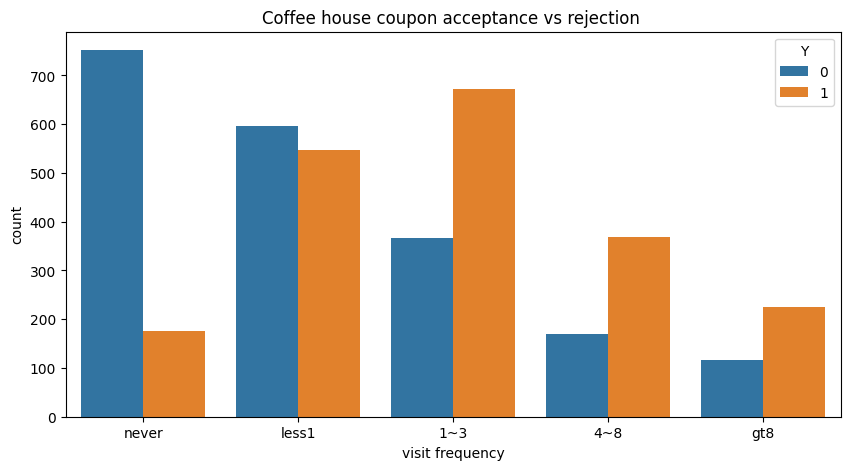

In [534]:
#comparing cofee coupon acceptance/rejection based on visiting frequency:

#setting natural order manually
visit_natural_order=['never','less1','1~3','4~8','gt8']

plt.figure(figsize=(10,5))
sns.countplot(data=coffee_coupon, x='CoffeeHouse', hue='Y',order=visit_natural_order)
plt.title('Coffee house coupon acceptance vs rejection ')
plt.xlabel('visit frequency')
plt.ylabel('count')

plt.show()


Observation

Drivers who never visit coffee houses were much more likely to reject the coupon than accept it. In contrast, drivers who visit coffee houses more frequently, especially those visiting 1–3 times or more than 4 times a month, showed noticeably higher acceptance rates.

This suggests that familiarity and existing interest in coffee house visits strongly influence whether a driver accepts a coffee coupon. People who already visit coffee houses regularly are naturally more likely to find the coupon useful.

Investigating How Weather and Temperature Affect Coffee Coupon Acceptance and Rejection

My hypothesis is that people may be more likely to accept coffee coupons during rainy or snowy weather because coffee feels warm and comforting in colder conditions. Based on this idea, I expect to see a lower acceptance rate for coffee coupons during hot and sunny days.

In [535]:
# filtering customers who likes to go to coffee house more than once in hot sunny weather 
hot_coupon= coffee_coupon[(coffee_coupon['weather']=='Sunny') & 
                          (coffee_coupon['temperature']==80) & 
                          (coffee_coupon['CoffeeHouse'].isin(['1~3','4~8','gt8']))]

#calculating acceptance rate

accptance_rate= hot_coupon['Y'].mean()

print(f'acceptance rate for customer who visits coffee house more than once a month in hot sunny day:.{accptance_rate}')


acceptance rate for customer who visits coffee house more than once a month in hot sunny day:.0.7161687170474517


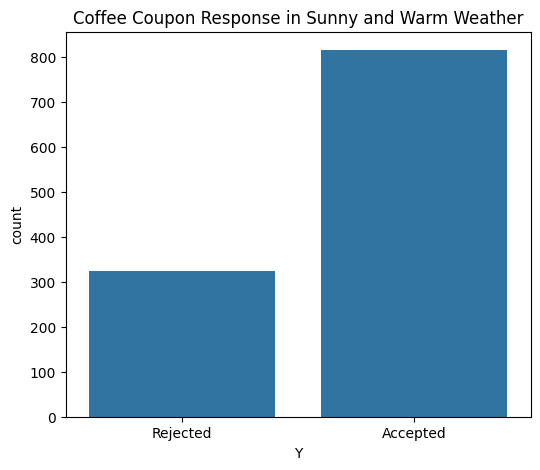

In [536]:
#visualization

plt.figure(figsize=(6,5))
sns.countplot(data=hot_coupon, x='Y')
plt.xticks([0,1], ['Rejected', 'Accepted'])
plt.title('Coffee Coupon Response in Sunny and Warm Weather')
plt.show()




Observation

Initially, I expected coffee coupons to be accepted more often during rainy or snowy weather since people may prefer warm drinks in colder conditions. However, the analysis showed a high acceptance rate (~72%) even during sunny weather with higher temperatures.

This suggests that drivers who regularly visit coffee houses may do so out of routine or lifestyle preference rather than weather conditions alone. Frequent coffee house visitors appear likely to accept coffee coupons regardless of whether the day is cold or warm.

time
6PM     0.410846
10PM    0.424242
7AM     0.445783
2PM     0.547289
10AM    0.640312
Name: Y, dtype: float64


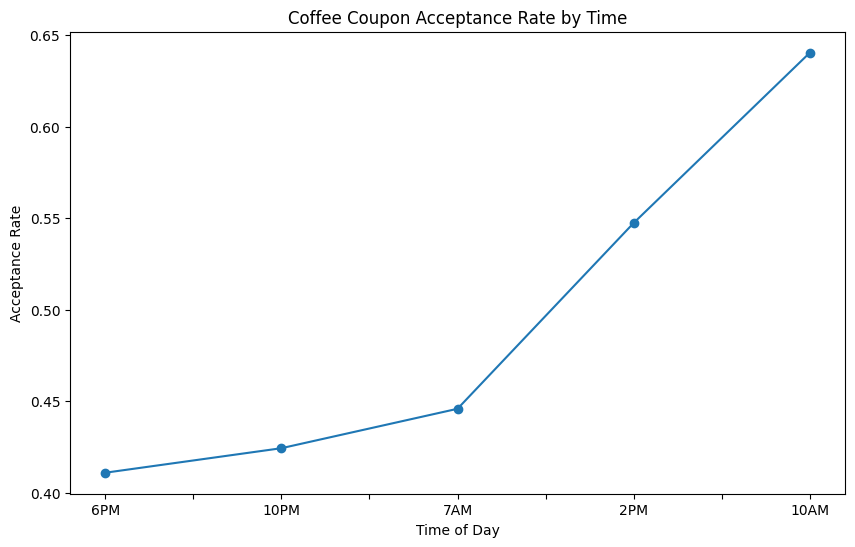

In [537]:
#Time of the day at which people are more likely to accept coupon
busiest_time=coffee_coupon.groupby('time')['Y'].mean().sort_values(ascending= True)
print(busiest_time)

plt.figure(figsize=(10,6))
busiest_time.plot(marker='o')
plt.ylabel('Acceptance Rate')
plt.xlabel('Time of Day')
plt.title('Coffee Coupon Acceptance Rate by Time')
plt.show()

Observation

The highest coffee coupon acceptance rate was observed at 10AM, followed by 2PM. Acceptance rates were noticeably lower during evening hours such as 6PM and 10PM.

This pattern suggests that drivers are more likely to accept coffee coupons during morning and early afternoon hours, likely because coffee consumption is strongly connected with daily routines, commuting, and work schedules.

Coffee House Visiting Behavior Across Demographic Groups

In this section, I explored which demographic groups appeared to visit coffee houses more frequently. The analysis focuses on gender, marital status, and occupation to better understand customer lifestyle patterns and coffee consumption behavior.



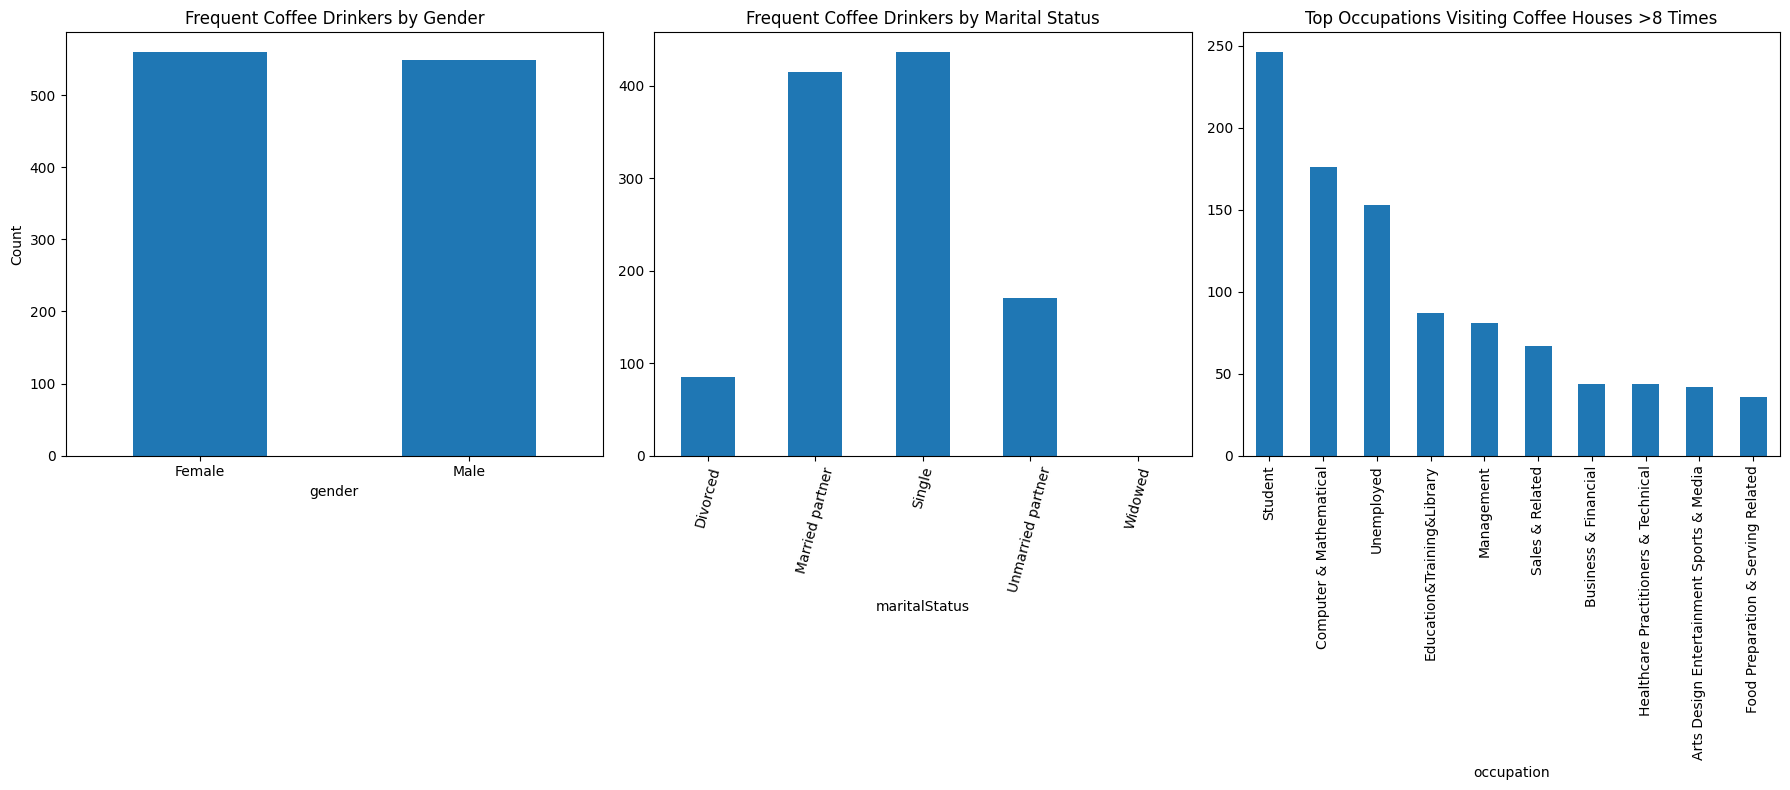

In [538]:

fig, axes = plt.subplots(1, 3, figsize=(18,8))

#Gender
gt8_gender = pd.crosstab(
    data_preprocessed['gender'],
    data_preprocessed['CoffeeHouse']
)['gt8']

gt8_gender.plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('Frequent Coffee Drinkers by Gender')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

#Marital Status
gt8_marital = pd.crosstab(
    data_preprocessed['maritalStatus'],
    data_preprocessed['CoffeeHouse']
)['gt8']

gt8_marital.plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title('Frequent Coffee Drinkers by Marital Status')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=75)

# Occupation
gt8_occupation = pd.crosstab(
    data_preprocessed['occupation'],
    data_preprocessed['CoffeeHouse']
)['gt8'].sort_values(ascending=False).head(10)

gt8_occupation.plot(
    kind='bar',
    ax=axes[2]
)

axes[2].set_title('Top Occupations Visiting Coffee Houses >8 Times')
axes[2].set_ylabel('')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Observation

The plots suggest that there is not a major difference between male and female customers when it comes to frequent coffee house visits, since both groups showed very similar counts.

More noticeable differences appeared across marital status and occupation groups. Single and married individuals seemed to visit coffee houses more frequently than divorced or widowed groups. Among occupations, students stood out as the most frequent coffee house visitors, followed by people working in computer and mathematical fields.

Overall, the results suggest that daily routine, work style, and lifestyle habits may influence coffee house visiting behavior more than gender alone.



---------------------------------Coffee Coupon-----------------------------------------

--------------------Key Findings------------------------------------------

. Customers who already visit coffee houses regularly were much more likely to accept coffee coupons.

. Customers who rarely visit coffee houses were more likely to reject the coupons.

. Coffee coupon acceptance was highest during morning and early afternoon hours, especially around 10AM.

. Drivers were less likely to accept coupons if the coffee shop required extra travel time or was located in the opposite direction.

. Students and people working in computer and mathematical fields appeared to visit coffee houses most frequently.

. There was no major difference between male and female customers in terms of frequent coffee house visits

--------------------------Actionable Items--------------------------------

. Coffee coupons may work best when targeted toward regular coffee house visitors.

. Sending coffee promotions during morning hours may improve coupon acceptance rates.

. Coupons for nearby coffee shops or locations along the customer’s route are more likely to be accepted.

. Lifestyle and occupation patterns may be more useful for targeting coffee promotions than gender alone.

. Students and technology-related professions may represent strong target groups for coffee-related marketing campaigns.
